# Did Apr-May actuals come in above or below April's forecast?

We hit a contradiction:
- Memory note `actuals-vs-april-overlap` claims **+105k above** April's forecast on average (Apr 1 — May 15, country=ALL, os=ALL).
- A fresh comparison on the no-Iran 45-tile aggregate showed **~−700k below** (28dMA).

This notebook resolves which is correct by directly loading the canonical desktop forecast parquets (raw model output and `.plus_iran.parquet`) and comparing against actuals (the `data_type='training'` rows in the June parquet, which are byte-identical to BQ raw data).

**Configurations tested:**
1. **No-Iran world** — April's `raw.parquet` (country=ALL, os=ALL) vs June's training rows
2. **Plus-Iran world** — April's `raw.plus_iran.parquet` vs June's `raw.plus_iran.parquet` training rows
3. **Headwind-adjusted April** — if the memory comparison was against `adj-h`, that would shift things

Goal: figure out which slice gave the +105k claim, and which slice is most relevant for understanding why June's trend lands lower than April's.


In [1]:
# setup
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

# Forecast output parquets (official-ish: same as what gets uploaded to BQ)
APRIL_DIR = Path("data-official/2026-04/desktop_cps0.15983_thresh050_recent13_clip0.6")
JUNE_DIR  = Path("data-official/2026-06/desktop_cps0.15983_thresh032_recent13_clip0.6_cap426")

APRIL_RAW  = APRIL_DIR / "mozaic_daily_forecast.2026-04-01.ld-D.raw.parquet"
JUNE_RAW   = JUNE_DIR  / "mozaic_daily_forecast.2026-05-17.ld-D.raw.parquet"
APRIL_PLUS = APRIL_DIR / "mozaic_daily_forecast.2026-04-01.ld-D.raw.plus_iran.parquet"
JUNE_PLUS  = JUNE_DIR  / "mozaic_daily_forecast.2026-05-17.ld-D.raw.plus_iran.parquet"

APRIL_FCST_START = pd.Timestamp("2026-04-01")
JUNE_FCST_START = pd.Timestamp("2026-05-17")
JUNE_TRAIN_END = JUNE_FCST_START - pd.Timedelta(days=1)  # 2026-05-16

def load_world_dau(path):
    """Return DataFrame with [target_date, data_type, dau] for the country=ALL, os=ALL row."""
    df = pd.read_parquet(path)
    world = df[(df.country == "ALL") & (df.segment == '{"os": "ALL"}')].copy()
    world["target_date"] = pd.to_datetime(world["target_date"])
    return world[["target_date", "data_type", "dau"]].sort_values("target_date")

# No-Iran (sum of 45 tiles)
april_raw = load_world_dau(APRIL_RAW)
june_raw  = load_world_dau(JUNE_RAW)
# Plus-Iran (world DAU with synthetic Iran added back)
april_plus = load_world_dau(APRIL_PLUS)
june_plus  = load_world_dau(JUNE_PLUS)

for name, df in [("april_raw", april_raw), ("june_raw", june_raw),
                  ("april_plus", april_plus), ("june_plus", june_plus)]:
    n_train = (df.data_type == "training").sum()
    n_fcst = (df.data_type == "forecast").sum()
    print(f"{name:<12}: train={n_train}, fcst={n_fcst}, "
          f"range {df.target_date.min().date()} -> {df.target_date.max().date()}")


april_raw   : train=2282, fcst=640, range 2020-01-01 -> 2027-12-31
june_raw    : train=2328, fcst=594, range 2020-01-01 -> 2027-12-31
april_plus  : train=2282, fcst=640, range 2020-01-01 -> 2027-12-31
june_plus   : train=2328, fcst=594, range 2020-01-01 -> 2027-12-31


In [2]:
# comparison-fn
def build_april_curve(april_parquet_df, fcst_start):
    """Stitch April's training (< fcst_start) + forecast (>= fcst_start) into one continuous series.

    Training rows in a forecast parquet are byte-identical to raw BQ actuals, so the
    stitched curve is "the model's view of the world": exact pre-fcst-start, predicted after.
    """
    train = april_parquet_df[(april_parquet_df.data_type == "training")
                              & (april_parquet_df.target_date < fcst_start)]
    fcst  = april_parquet_df[(april_parquet_df.data_type == "forecast")
                              & (april_parquet_df.target_date >= fcst_start)]
    return pd.concat([train, fcst], ignore_index=True).sort_values("target_date").reset_index(drop=True)


def build_actuals_curve(june_parquet_df):
    """Actuals come from training rows in the June parquet — extends past April's training-end."""
    return june_parquet_df[june_parquet_df.data_type == "training"].sort_values("target_date").reset_index(drop=True)


def compare_actuals_vs_forecast(actuals_series, april_curve, label, window_start, window_end):
    """
    actuals_series, april_curve: full continuous DataFrames with [target_date, dau].
    Rolling 28dMA is computed on the FULL series (training history seeds the window),
    then sliced to [window_start, window_end] for delta + summary.
    """
    a = actuals_series.copy().rename(columns={"dau": "actuals"})
    f = april_curve.copy().rename(columns={"dau": "forecast"})
    a["actuals_ma28"]  = a["actuals"].rolling(28, min_periods=28).mean()
    f["forecast_ma28"] = f["forecast"].rolling(28, min_periods=28).mean()

    m = a[["target_date", "actuals", "actuals_ma28"]].merge(
        f[["target_date", "forecast", "forecast_ma28"]], on="target_date", how="inner",
    )
    m = m[(m.target_date >= window_start) & (m.target_date <= window_end)].sort_values("target_date").reset_index(drop=True)
    m["delta"] = m["actuals"] - m["forecast"]
    m["ma_delta"] = m["actuals_ma28"] - m["forecast_ma28"]

    summary = {
        "label": label,
        "n_days": len(m),
        "raw_pct_above":    (m["delta"] > 0).mean(),
        "raw_mean_delta":    m["delta"].mean(),
        "raw_median_delta":  m["delta"].median(),
        "ma_mean_delta":     m["ma_delta"].mean(),
        "ma_pct_above":     (m["ma_delta"] > 0).mean() if m["ma_delta"].notna().any() else np.nan,
        "ma_n_days":         m["ma_delta"].notna().sum(),
    }
    return m, summary


def plot_comparison(m, summary, ax, color="purple", label_prefix=""):
    ax.plot(m["target_date"], m["actuals_ma28"], color="black", lw=1.8,
            label=f"{label_prefix}actuals (28d MA)")
    ax.plot(m["target_date"], m["forecast_ma28"], color=color, lw=1.5,
            label=f"{label_prefix}April fcst (28d MA)")
    ax.plot(m["target_date"], m["actuals"], color="black", lw=0.5, alpha=0.4,
            label=f"{label_prefix}actuals (raw)")
    ax.plot(m["target_date"], m["forecast"], color=color, lw=0.5, alpha=0.4,
            label=f"{label_prefix}April fcst (raw)")
    ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
    ax.set_ylabel("DAU")
    ax.legend(loc="lower left", fontsize=8)


## March → now: actuals vs raw April forecast (no headwinds)

Single focused view. April's forecast horizon starts 2026-04-01, so Mar 2026 is just the actuals tail; from Apr 1 forward we overlay April's raw forecast against what actually came in.


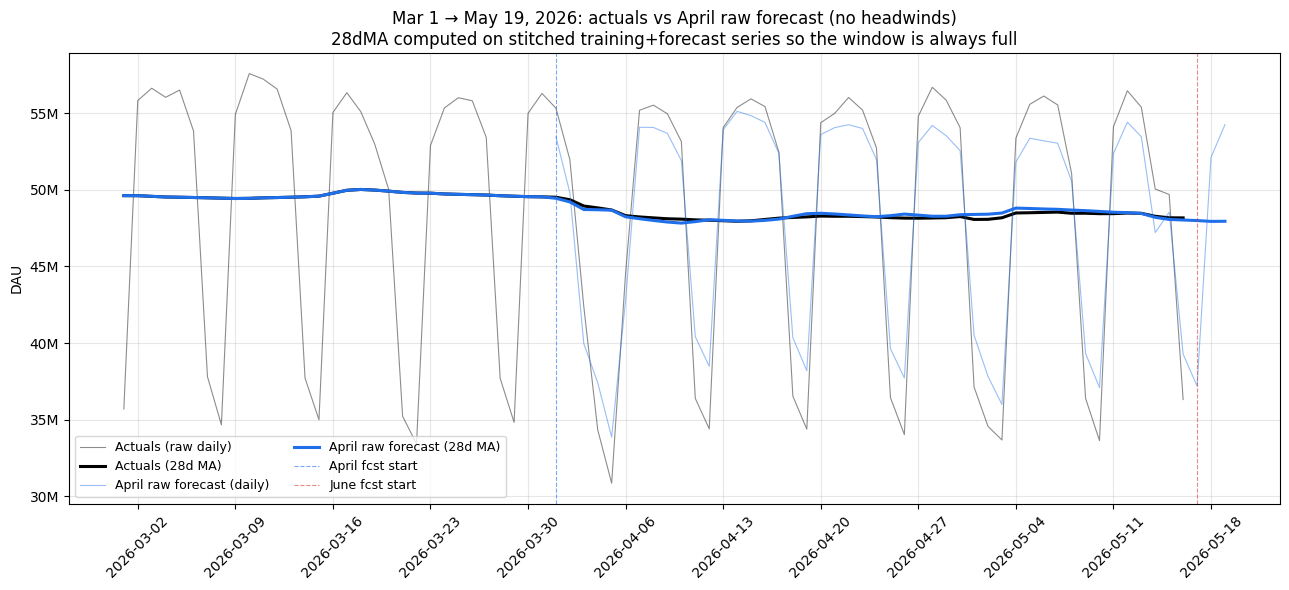

In [3]:
# plot-march-now
WIN_START = pd.Timestamp("2026-03-01")
WIN_END = pd.Timestamp("2026-05-19")

# Build a continuous April "model curve" by stitching training + forecast.
# Training rows give us pre-Apr-1 history to seed the rolling MA properly.
april_series = april_raw.copy().sort_values("target_date").reset_index(drop=True)
# For Apr 1 onward, keep the forecast row; for pre-Apr-1, keep the training row
# (training rows = raw actuals — same data Prophet saw — so stitching is exact).
april_curve = pd.concat([
    april_series[(april_series.data_type == "training")
                 & (april_series.target_date < APRIL_FCST_START)],
    april_series[(april_series.data_type == "forecast")
                 & (april_series.target_date >= APRIL_FCST_START)],
], ignore_index=True).sort_values("target_date").reset_index(drop=True)

# Actuals: continuous training from June parquet (extends past Apr 1)
june_actuals = june_raw[june_raw.data_type == "training"].sort_values("target_date").reset_index(drop=True)

# Compute 28dMA on the FULL series, then clip to the plot window
april_curve["dau_ma28"] = april_curve["dau"].rolling(28, min_periods=28).mean()
june_actuals["dau_ma28"] = june_actuals["dau"].rolling(28, min_periods=28).mean()

def clip(df, start, end):
    return df[(df.target_date >= start) & (df.target_date <= end)].copy()

actuals = clip(june_actuals, WIN_START, WIN_END)
fcst = clip(april_curve, WIN_START, WIN_END)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(actuals["target_date"], actuals["dau"],
        color="black", lw=0.8, alpha=0.45, label="Actuals (raw daily)")
ax.plot(actuals["target_date"], actuals["dau_ma28"],
        color="black", lw=2.2, label="Actuals (28d MA)")
# April curve: solid before Apr 1 (=actuals, identical to black), then the forecast.
# Plot daily only over the forecast portion to avoid double-drawing actuals.
april_pre = clip(fcst[fcst.target_date < APRIL_FCST_START], WIN_START, WIN_END)
april_post = clip(fcst[fcst.target_date >= APRIL_FCST_START], WIN_START, WIN_END)
ax.plot(april_post["target_date"], april_post["dau"],
        color="#1f6feb", lw=0.8, alpha=0.45, label="April raw forecast (daily)")
ax.plot(fcst["target_date"], fcst["dau_ma28"],
        color="#1f6feb", lw=2.2, label="April raw forecast (28d MA)")

ax.axvline(APRIL_FCST_START, color="#1f6feb", ls="--", lw=0.8, alpha=0.6,
           label="April fcst start")
ax.axvline(JUNE_FCST_START, color="#d63a3a", ls="--", lw=0.8, alpha=0.6,
           label="June fcst start")

ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
ax.set_ylabel("DAU")
ax.set_title("Mar 1 → May 19, 2026: actuals vs April raw forecast (no headwinds)\n"
             "28dMA computed on stitched training+forecast series so the window is always full")
ax.legend(loc="lower left", fontsize=9, ncol=2)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## Configuration 1: No-Iran world (raw model output)

This is the sum of all 45 desktop tiles, no Iran add-back. April's `raw.parquet` country=ALL row vs June's training rows on the same dates.


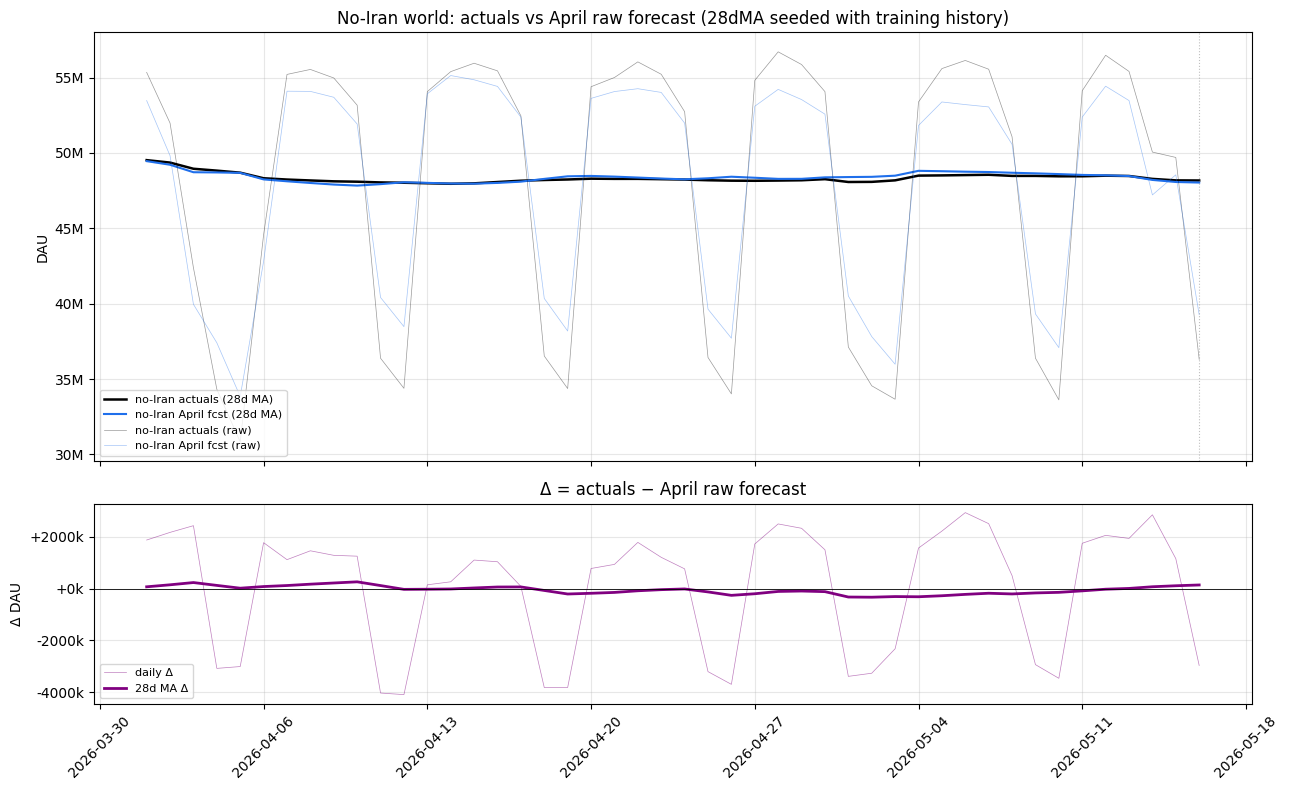

=== No-Iran world (46 days; 28dMA over 46 days) ===
  Raw daily: 70% above, mean Δ = +38.4k, median Δ = +1105.5k
  28d MA:    39% above, mean Δ = -52.0k


In [4]:
# plot-noiran
april_curve_noiran = build_april_curve(april_raw, APRIL_FCST_START)
actuals_noiran    = build_actuals_curve(june_raw)

m_noiran, sum_noiran = compare_actuals_vs_forecast(
    actuals_noiran, april_curve_noiran, "No-Iran world",
    APRIL_FCST_START, JUNE_TRAIN_END,
)

fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                          gridspec_kw={"height_ratios": [3, 1.4]}, sharex=True)
plot_comparison(m_noiran, sum_noiran, axes[0], color="#1f6feb",
                label_prefix="no-Iran ")
axes[0].set_title("No-Iran world: actuals vs April raw forecast (28dMA seeded with training history)")
axes[0].axvline(JUNE_TRAIN_END, color="grey", ls=":", lw=0.8, alpha=0.5)

ax = axes[1]
ax.plot(m_noiran["target_date"], m_noiran["delta"], color="purple", lw=0.5, alpha=0.5,
        label="daily Δ")
ax.plot(m_noiran["target_date"], m_noiran["ma_delta"], color="purple", lw=2.0,
        label="28d MA Δ")
ax.axhline(0, color="black", lw=0.6)
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:+.0f}k"))
ax.set_title("Δ = actuals − April raw forecast")
ax.set_ylabel("Δ DAU")
ax.legend(loc="best", fontsize=8)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"=== No-Iran world ({sum_noiran['n_days']} days; 28dMA over {sum_noiran['ma_n_days']} days) ===")
print(f"  Raw daily: {sum_noiran['raw_pct_above']:.0%} above, "
      f"mean Δ = {sum_noiran['raw_mean_delta']/1e3:+.1f}k, "
      f"median Δ = {sum_noiran['raw_median_delta']/1e3:+.1f}k")
print(f"  28d MA:    {sum_noiran['ma_pct_above']:.0%} above, "
      f"mean Δ = {sum_noiran['ma_mean_delta']/1e3:+.1f}k")


## Configuration 2: Plus-Iran world

Same as above but using the `.plus_iran.parquet` files, which add synthetic Iran DAU back into the world aggregate. This is closer to what would appear on a "world DAU" dashboard during the Iran shutdown era.


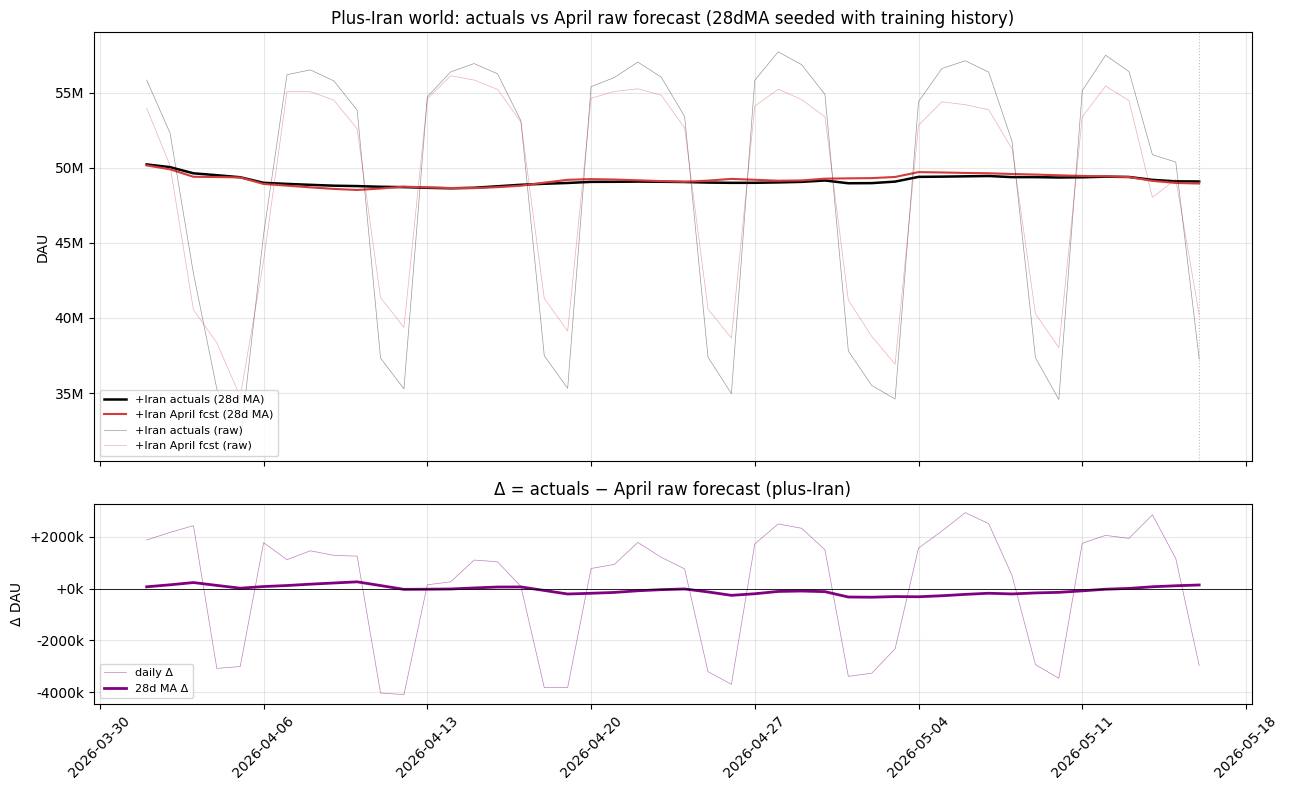

=== Plus-Iran world (46 days; 28dMA over 46 days) ===
  Raw daily: 70% above, mean Δ = +38.4k, median Δ = +1105.5k
  28d MA:    39% above, mean Δ = -52.0k


In [5]:
# plot-plusiran
april_curve_plus = build_april_curve(april_plus, APRIL_FCST_START)
actuals_plus     = build_actuals_curve(june_plus)

m_plus, sum_plus = compare_actuals_vs_forecast(
    actuals_plus, april_curve_plus, "Plus-Iran world",
    APRIL_FCST_START, JUNE_TRAIN_END,
)

fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                          gridspec_kw={"height_ratios": [3, 1.4]}, sharex=True)
plot_comparison(m_plus, sum_plus, axes[0], color="#d63a3a",
                label_prefix="+Iran ")
axes[0].set_title("Plus-Iran world: actuals vs April raw forecast (28dMA seeded with training history)")
axes[0].axvline(JUNE_TRAIN_END, color="grey", ls=":", lw=0.8, alpha=0.5)

ax = axes[1]
ax.plot(m_plus["target_date"], m_plus["delta"], color="purple", lw=0.5, alpha=0.5,
        label="daily Δ")
ax.plot(m_plus["target_date"], m_plus["ma_delta"], color="purple", lw=2.0,
        label="28d MA Δ")
ax.axhline(0, color="black", lw=0.6)
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:+.0f}k"))
ax.set_title("Δ = actuals − April raw forecast (plus-Iran)")
ax.set_ylabel("Δ DAU")
ax.legend(loc="best", fontsize=8)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"=== Plus-Iran world ({sum_plus['n_days']} days; 28dMA over {sum_plus['ma_n_days']} days) ===")
print(f"  Raw daily: {sum_plus['raw_pct_above']:.0%} above, "
      f"mean Δ = {sum_plus['raw_mean_delta']/1e3:+.1f}k, "
      f"median Δ = {sum_plus['raw_median_delta']/1e3:+.1f}k")
print(f"  28d MA:    {sum_plus['ma_pct_above']:.0%} above, "
      f"mean Δ = {sum_plus['ma_mean_delta']/1e3:+.1f}k")


## Configuration 3: Headwind-adjusted (`adj-h`) April forecast

If the memory comparison was against the headwind-adjusted April forecast (e.g., the final composite shipped to stakeholders), that would be lower than raw — making actuals look *higher* relative to it.

Look at `data-official/2026-04/adjustments/headwind.json` to see what the April headwind looked like.


April headwind config: {'type': 'linear_ramp', 'start_date': '2026-04-01', 'anchor_date': '2026-12-15', 'desktop_dau': -1497870, 'mobile_dau': -27162}


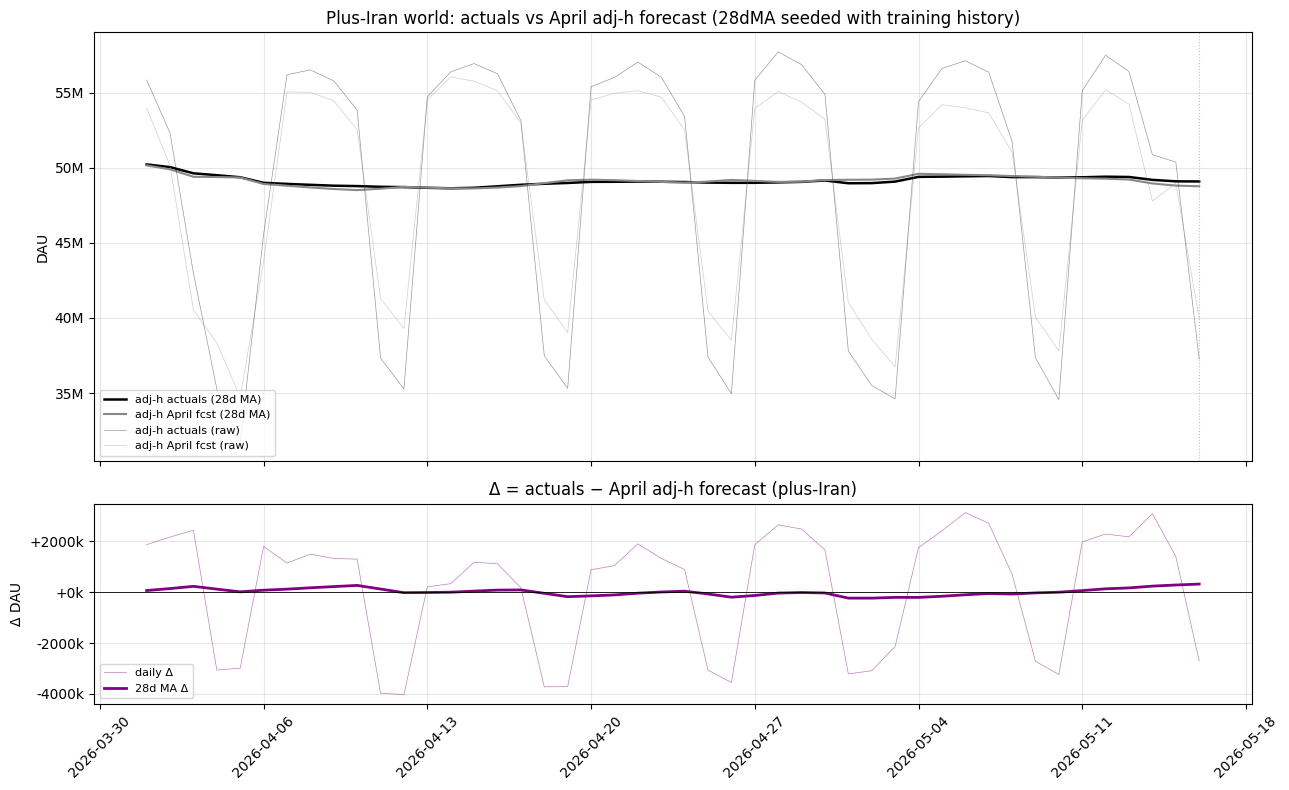


=== Plus-Iran + April adj-h (46 days; 28dMA over 46 days) ===
  Raw daily: 70% above, mean Δ = +169.0k, median Δ = +1163.6k
  28d MA:    52% above, mean Δ = +16.7k


In [6]:
# plot-adjh
import json
with open(APRIL_DIR.parent / "adjustments" / "headwind.json") as f:
    headwind = json.load(f)
print(f"April headwind config: {headwind}")

start = pd.Timestamp(headwind["start_date"])
anchor = pd.Timestamp(headwind["anchor_date"])
total_days = (anchor - start).days
desktop_target = headwind["desktop_dau"]

def headwind_value(d):
    days_in = (d - start).days
    if days_in < 0:
        return 0.0
    if days_in >= total_days:
        return desktop_target
    return desktop_target * (days_in / total_days)

april_curve_adjh = build_april_curve(april_plus, APRIL_FCST_START).copy()
mask_fcst = april_curve_adjh.target_date >= APRIL_FCST_START
april_curve_adjh.loc[mask_fcst, "dau"] = (
    april_curve_adjh.loc[mask_fcst, "dau"]
    + april_curve_adjh.loc[mask_fcst, "target_date"].map(headwind_value)
)

m_adjh, sum_adjh = compare_actuals_vs_forecast(
    actuals_plus, april_curve_adjh, "Plus-Iran + April adj-h",
    APRIL_FCST_START, JUNE_TRAIN_END,
)

fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                          gridspec_kw={"height_ratios": [3, 1.4]}, sharex=True)
plot_comparison(m_adjh, sum_adjh, axes[0], color="#888",
                label_prefix="adj-h ")
axes[0].set_title("Plus-Iran world: actuals vs April adj-h forecast (28dMA seeded with training history)")
axes[0].axvline(JUNE_TRAIN_END, color="grey", ls=":", lw=0.8, alpha=0.5)

ax = axes[1]
ax.plot(m_adjh["target_date"], m_adjh["delta"], color="purple", lw=0.5, alpha=0.5,
        label="daily Δ")
ax.plot(m_adjh["target_date"], m_adjh["ma_delta"], color="purple", lw=2.0,
        label="28d MA Δ")
ax.axhline(0, color="black", lw=0.6)
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:+.0f}k"))
ax.set_title("Δ = actuals − April adj-h forecast (plus-Iran)")
ax.set_ylabel("Δ DAU")
ax.legend(loc="best", fontsize=8)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(f"\n=== Plus-Iran + April adj-h ({sum_adjh['n_days']} days; 28dMA over {sum_adjh['ma_n_days']} days) ===")
print(f"  Raw daily: {sum_adjh['raw_pct_above']:.0%} above, "
      f"mean Δ = {sum_adjh['raw_mean_delta']/1e3:+.1f}k, "
      f"median Δ = {sum_adjh['raw_median_delta']/1e3:+.1f}k")
print(f"  28d MA:    {sum_adjh['ma_pct_above']:.0%} above, "
      f"mean Δ = {sum_adjh['ma_mean_delta']/1e3:+.1f}k")


## Summary

The cell below collates the three configurations side by side. The memory note's "+105k above" claim is one of these or it isn't — the table will resolve which.


In [7]:
# summary-table
rows = []
for s in [sum_noiran, sum_plus, sum_adjh]:
    rows.append({
        "configuration": s["label"],
        "n_days": s["n_days"],
        "raw % above": f"{s['raw_pct_above']:.0%}",
        "raw mean Δ": f"{s['raw_mean_delta']/1e3:+.1f}k",
        "raw median Δ": f"{s['raw_median_delta']/1e3:+.1f}k",
        "28dMA mean Δ": f"{s['ma_mean_delta']/1e3:+.1f}k",
        "28dMA % above": f"{s['ma_pct_above']:.0%}" if pd.notna(s["ma_pct_above"]) else "—",
    })
summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
print()
print("Memory's claim was +105k above April's forecast on average.")
print("Which row matches? Read columns: 'raw mean Δ' and '28dMA mean Δ'.")


          configuration  n_days raw % above raw mean Δ raw median Δ 28dMA mean Δ 28dMA % above
          No-Iran world      46         70%     +38.4k     +1105.5k       -52.0k           39%
        Plus-Iran world      46         70%     +38.4k     +1105.5k       -52.0k           39%
Plus-Iran + April adj-h      46         70%    +169.0k     +1163.6k       +16.7k           52%

Memory's claim was +105k above April's forecast on average.
Which row matches? Read columns: 'raw mean Δ' and '28dMA mean Δ'.
